# Phase 6P-0：论文 NDC 原位复现结果

本 notebook 是一次**只读结果复核**：读取已冻结的 CSV、JSON 和模型产物，不重新训练，也不改变测试轨迹。

**最终结论：Phase 6P-0 阳性对照通过。** 冻结测试离线 NRMSE 与闭环电流 NRMSE 均低于 1%，30/30 条 DNN 轨迹到达目标，约束违约保持在 (10^{-2}) 以内，且 4/5 个随机种子在内部测试上重复通过。

## 1. 论文合同与复现边界

【论文原文】Shokry 等，*Computers & Chemical Engineering* 199 (2025) 109096：

- PDF 第 11 页、式 (12)–(24)：NDC 两状态 (V_s,V_b)，60 s 周期，(N_p=10,N_u=2,N_c=1)，电流 0–3 A、(V_sle0.95) V、端电压不超过 4.2 V，并施加健康约束。
- PDF 第 11–12 页、图 6–7：324 个 Hammersley 点加 76 个全因子点，每个初态闭环展开 5 步；DNN 为 2–7–5–3–1 sigmoid，使用 BR-LMB，训练/内部测试随机 90/10。
- PDF 第 12–13 页、表 3–4：30 条独立闭环测试轨迹；论文报告开环 NRMSE 0.90%、闭环 NRMSE 0.38%。

【复现假设】论文未报告随机种子、76 个边界点的具体水平、归一化及 BR-LMB 超参数。本实现冻结这些选择并写入中文报告。由于网络输入只有 ((V_s,V_b))，教师目标中的电流变化惩罚只作用于两个 CVP 预测块之间，避免未观测历史电流使标签成为非单值映射。

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "outputs" / "phase6p0_ndc_paper").exists():
    ROOT = ROOT.parent
OUT = ROOT / "outputs" / "phase6p0_ndc_paper"

metrics = json.loads((OUT / "metrics.json").read_text(encoding="utf-8"))
seeds = pd.read_csv(OUT / "seed_metrics.csv")
initial_states = pd.read_csv(OUT / "training_initial_states.csv")
training = pd.read_csv(OUT / "training_teacher_2000.csv")
test_initial = pd.read_csv(OUT / "frozen_test_initial_states_30.csv")
teacher = pd.read_csv(OUT / "frozen_test_mpc_trajectories.csv")
dnn = pd.read_csv(OUT / "frozen_test_dnn_closed_loop.csv")
trajectory_metrics = pd.read_csv(OUT / "closed_loop_trajectory_metrics.csv")

print(f"结果目录：{OUT.resolve()}")
print(f"总体判定：{'通过' if metrics['success'] else '未通过'}")

结果目录：C:\Users\LENOVO\Documents\动力电池AI\outputs\phase6p0_ndc_paper
总体判定：通过


## 2. 冻结数据合同

In [2]:
contract = pd.DataFrame([
    ["训练初态", len(initial_states), 400],
    ["Hammersley 初态", (initial_states.sampling_method == "hammersley").sum(), 324],
    ["边界全因子初态", (initial_states.sampling_method == "boundary_factorial").sum(), 76],
    ["监督样本", len(training), 2000],
    ["冻结测试轨迹", test_initial.trajectory_id.nunique(), 30],
    ["冻结测试样本", len(teacher), 4500],
], columns=["合同项", "实际", "要求"])
contract["一致"] = contract["实际"] == contract["要求"]
display(contract)
assert contract["一致"].all()
assert teacher.groupby("trajectory_id").size().eq(150).all()

,合同项,实际,要求,一致
0,训练初态,400,400,True
1,Hammersley 初态,324,324,True
2,边界全因子初态,76,76,True
3,监督样本,2000,2000,True
4,冻结测试轨迹,30,30,True
5,冻结测试样本,4500,4500,True


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\2889015470.py:8: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\2889015470.py:8: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\2889015470.py:8: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\2889015470.py:8: UserWarning: Glyph 21387 (\N{CJK UNIFIED IDEOGRAPH-538B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\2889015470.py:8: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\2889015470.py:8: UserWarning: Glyph 38754 (\

C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30417 (\N{CJK UNIFIED IDEOGRAPH-76D1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtoo

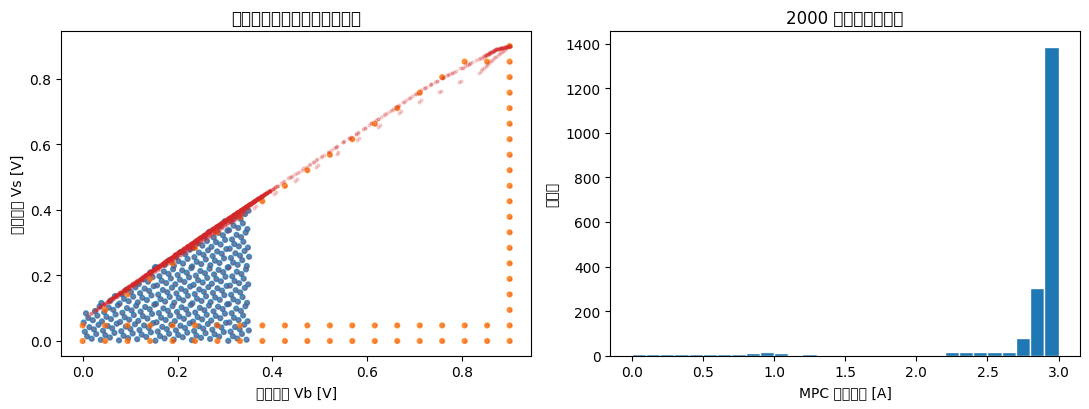

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
colors = initial_states.sampling_method.map({"hammersley": "tab:blue", "boundary_factorial": "tab:orange"})
axes[0].scatter(initial_states.bulk_voltage_v, initial_states.surface_voltage_v, s=12, c=colors, alpha=0.75)
axes[0].scatter(training.bulk_voltage_v, training.surface_voltage_v, s=4, c="tab:red", alpha=0.18)
axes[0].set(xlabel="体相电压 Vb [V]", ylabel="表面电压 Vs [V]", title="混合初态与五步闭环展开状态")
axes[1].hist(training.teacher_current_a, bins=30, color="tab:blue", edgecolor="white")
axes[1].set(xlabel="MPC 最优电流 [A]", ylabel="样本数", title="2000 个监督标签分布")
plt.tight_layout()
plt.show()

## 3. 五随机种子重复性

,seed,internal_test_nrmse_percent,internal_test_rmse_a,bayesian_updates_completed,function_evaluations,低于1%
0,11,4.6958,0.140873,6,6069,False
1,29,0.0385,0.001154,6,7093,True
2,47,0.1286,0.003857,6,6583,True
3,71,0.0049,0.000148,6,6732,True
4,101,0.1192,0.003575,6,6707,True


通过种子：4/5
均值 ± 标准差：0.9974% ± 2.0681%


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\2309416947.py:12: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\2309416947.py:12: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\2309416947.py:12: UserWarning: Glyph 31181 (\N{CJK UNIFIED IDEOGRAPH-79CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\2309416947.py:12: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\2309416947.py:12: UserWarning: Glyph 20869 (\N{CJK UNIFIED IDEOGRAPH-5185}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\2309416947.py:12: UserWarning: Glyph 37

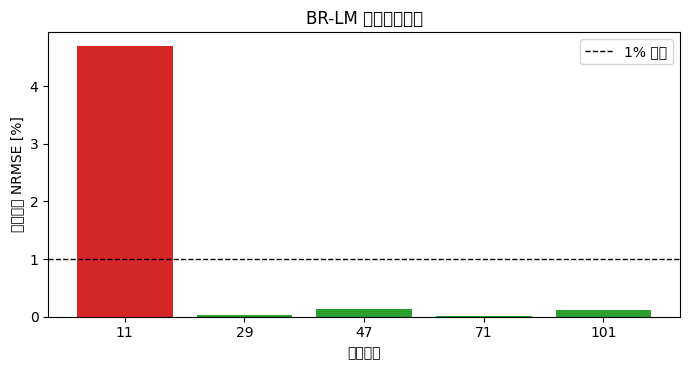

In [4]:
seed_view = seeds[["seed", "internal_test_nrmse_percent", "internal_test_rmse_a", "bayesian_updates_completed", "function_evaluations"]].copy()
seed_view["低于1%"] = seed_view.internal_test_nrmse_percent < 1.0
display(seed_view.style.format({"internal_test_nrmse_percent": "{:.4f}", "internal_test_rmse_a": "{:.6f}"}))
print(f"通过种子：{seed_view['低于1%'].sum()}/{len(seed_view)}")
print(f"均值 ± 标准差：{seed_view.internal_test_nrmse_percent.mean():.4f}% ± {seed_view.internal_test_nrmse_percent.std(ddof=1):.4f}%")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(seed_view.seed.astype(str), seed_view.internal_test_nrmse_percent, color=np.where(seed_view["低于1%"], "tab:green", "tab:red"))
ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="1% 门槛")
ax.set(xlabel="随机种子", ylabel="内部测试 NRMSE [%]", title="BR-LM 初始化重复性")
ax.legend()
plt.tight_layout()
plt.show()

【结果解释】4/5 个种子低于 1%，满足“多数种子重复通过”。种子 11 仍失败，说明 BR-LM 对初始化并非完全稳定；因此论文阳性对照成立，但后续迁移实验仍必须保留多种子统计，不能只报告最佳一次。

## 4. 冻结测试验收

In [5]:
gates = metrics["gates"]
summary = pd.DataFrame([
    ["离线 NRMSE", metrics["offline"]["nrmse_percent"], "< 1%", gates["offline_nrmse"]],
    ["闭环平均电流 NRMSE", metrics["closed_loop"]["mean_trajectory_current_nrmse_percent"], "< 1%", gates["closed_loop_current_nrmse"]],
    ["闭环最差轨迹 NRMSE", metrics["closed_loop"]["maximum_trajectory_current_nrmse_percent"], "诊断项", True],
    ["目标到达率 [%]", 100 * metrics["closed_loop"]["target_reach_fraction"], "100%", gates["target_reach"]],
    ["最大约束违约 [A/V]", metrics["maximum_constraint_violation"], "≤ 1e-2", gates["constraint_violation"]],
    ["MPC/DNN 在线加速倍数", metrics["closed_loop"]["timing"]["speedup"], "> 2x", gates["speedup"]],
    ["通过种子数", metrics["network"]["passing_seed_count"], "> 2.5/5", gates["majority_seeds"]],
], columns=["指标", "结果", "门槛", "通过"])
display(summary.style.format({"结果": "{:.6g}"}))
assert metrics["success"] and all(gates.values())

,指标,结果,门槛,通过
0,离线 NRMSE,0.0369303,< 1%,True
1,闭环平均电流 NRMSE,0.032556,< 1%,True
2,闭环最差轨迹 NRMSE,0.229682,诊断项,True
3,目标到达率 [%],100,100%,True
4,最大约束违约 [A/V],0.00527583,≤ 1e-2,True
5,MPC/DNN 在线加速倍数,78.249,> 2x,True
6,通过种子数,4,> 2.5/5,True


In [6]:
violations = metrics["closed_loop"]["constraint_violations"]
violation_table = pd.DataFrame([
    ["电流上界", violations["current_upper_average_a"], violations["current_upper_maximum_a"]],
    ["电流下界", violations["current_lower_average_a"], violations["current_lower_maximum_a"]],
    ["表面电压", violations["surface_voltage_average_v"], violations["surface_voltage_maximum_v"]],
    ["端电压", violations["terminal_voltage_average_v"], violations["terminal_voltage_maximum_v"]],
    ["健康约束", violations["health_average_v"], violations["health_maximum_v"]],
], columns=["约束", "平均正违约 [A/V]", "最大正违约 [A/V]"])
display(violation_table.style.format({"平均正违约 [A/V]": "{:.3e}", "最大正违约 [A/V]": "{:.3e}"}))

,约束,平均正违约 [A/V],最大正违约 [A/V]
0,电流上界,3.732e-08,1.547e-04
1,电流下界,0.000e+00,0.000e+00
2,表面电压,0.000e+00,0.000e+00
3,端电压,3.656e-06,5.276e-03
4,健康约束,1.333e-07,4.661e-05


## 5. 代表性闭环轨迹

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\4007021850.py:20: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\4007021850.py:20: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\4007021850.py:20: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\4007021850.py:20: UserWarning: Glyph 38381 (\N{CJK UNIFIED IDEOGRAPH-95ED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\4007021850.py:20: UserWarning: Glyph 29615 (\N{CJK UNIFIED IDEOGRAPH-73AF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\4007021850.py:20: UserWarning: Glyph 25511 (\N{CJK UNIFIED IDEOGRAPH-63A7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\4007021850.py:20: UserWarning: Glyph 21046 (\N{CJK UNIFIED IDEOGRAPH-5236}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15816\4007021850.py:20: UserWarning: Glyph 27

C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38381 (\N{CJK UNIFIED IDEOGRAPH-95ED}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtoo

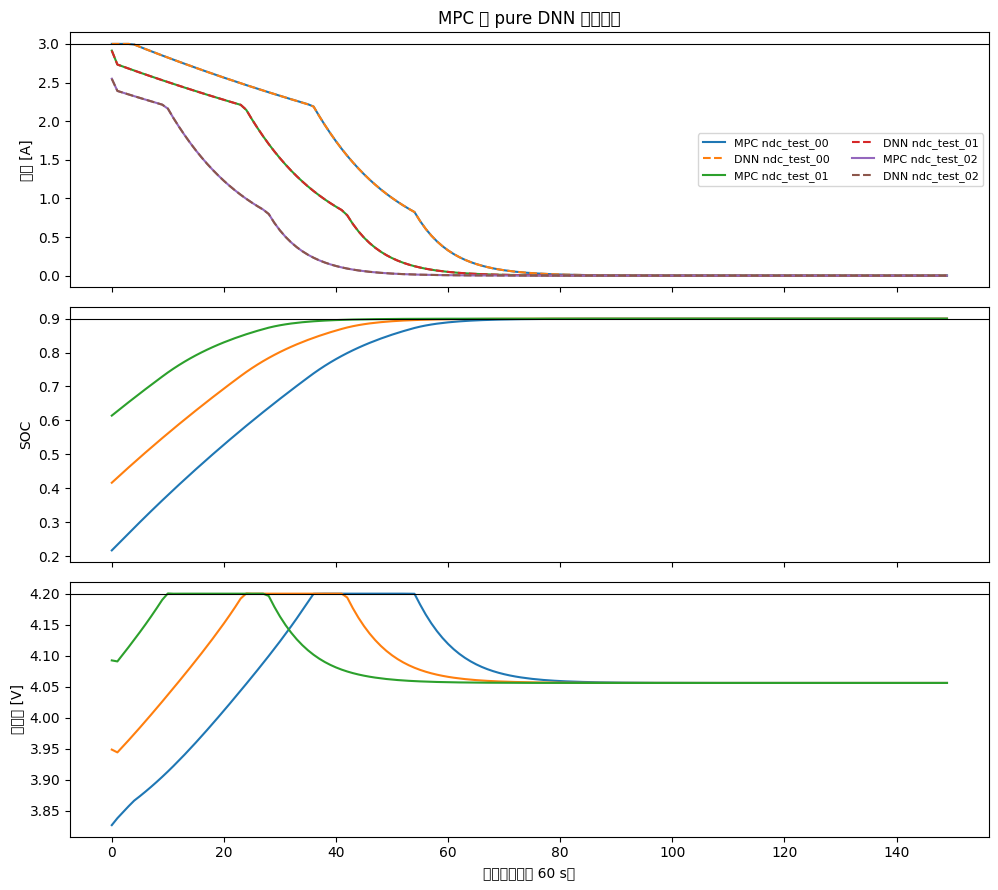

In [7]:
paired = teacher[["trajectory_id", "step_index", "teacher_current_a", "next_soc", "next_terminal_voltage_v"]].merge(
    dnn[["trajectory_id", "step_index", "dnn_current_a", "next_soc", "next_terminal_voltage_v"]],
    on=["trajectory_id", "step_index"], suffixes=("_mpc", "_dnn"), validate="one_to_one"
)
selected_ids = ["ndc_test_00", "ndc_test_01", "ndc_test_02"]
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for trajectory_id, group in paired[paired.trajectory_id.isin(selected_ids)].groupby("trajectory_id"):
    time_min = group.step_index.to_numpy()
    axes[0].plot(time_min, group.teacher_current_a, label=f"MPC {trajectory_id}")
    axes[0].plot(time_min, group.dnn_current_a, "--", label=f"DNN {trajectory_id}")
    axes[1].plot(time_min, group.next_soc_dnn, label=trajectory_id)
    axes[2].plot(time_min, group.next_terminal_voltage_v_dnn, label=trajectory_id)
axes[0].axhline(3.0, color="black", linewidth=0.8)
axes[0].set(ylabel="电流 [A]", title="MPC 与 pure DNN 闭环电流")
axes[0].legend(ncol=2, fontsize=8)
axes[1].axhline(0.9, color="black", linewidth=0.8)
axes[1].set(ylabel="SOC")
axes[2].axhline(4.2, color="black", linewidth=0.8)
axes[2].set(xlabel="控制步（每步 60 s）", ylabel="端电压 [V]")
plt.tight_layout()
plt.show()

In [8]:
display(trajectory_metrics.sort_values("current_nrmse_percent", ascending=False).head(10).style.format({
    "current_nrmse_percent": "{:.4f}", "maximum_current_error_a": "{:.5f}", "final_soc": "{:.6f}"
}))

,trajectory_id,current_nrmse_percent,maximum_current_error_a,final_soc,target_reached
15,ndc_test_15,0.2297,0.05503,0.900003,True
4,ndc_test_04,0.1897,0.02794,0.900003,True
9,ndc_test_09,0.1028,0.01453,0.900003,True
23,ndc_test_23,0.0733,0.01132,0.900003,True
8,ndc_test_08,0.0732,0.02303,0.900003,True
11,ndc_test_11,0.0509,0.01810,0.900003,True
27,ndc_test_27,0.0274,0.00628,0.900003,True
24,ndc_test_24,0.0185,0.00509,0.900003,True
10,ndc_test_10,0.0162,0.00503,0.900003,True
5,ndc_test_05,0.0145,0.00273,0.900003,True


## 6. 阶段决策

【证据支持的结论】论文式 DNN 显式 MPC 方法能够在当前代码框架中成立。此前 Phase 6 Chen2020 迁移失败不能再优先归因于“基础 DNN 管线整体错误”，而应转向模型、硬斜率、高频控制、模型失配和分布外泛化条件。

【结论边界】由于论文未报告部分采样、归一化和 BR-LMB 细节，本实验是功能性阳性对照，不是逐比特数值复刻；本实现误差低于论文表 3，不代表方法优于论文。

【下一步】进入第二阶段 **Chen2020 Phase 2R 模型充分性审计**，不训练新 ANN。完成 65%、70%、75%、80% SOC，在 15/25/30 ℃下的脉冲与 5/25/300 s 预测误差审计后，再决定是否进入 A1–A7 消融。